In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

import joblib

In [2]:
# Load Dataset

df = pd.read_csv("AmesHousing.csv")

print(df.head())
print(df.shape)

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [3]:
# Data Exploration

print(df.info())

print(df.describe())

print(df.isnull().sum().sort_values(ascending=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

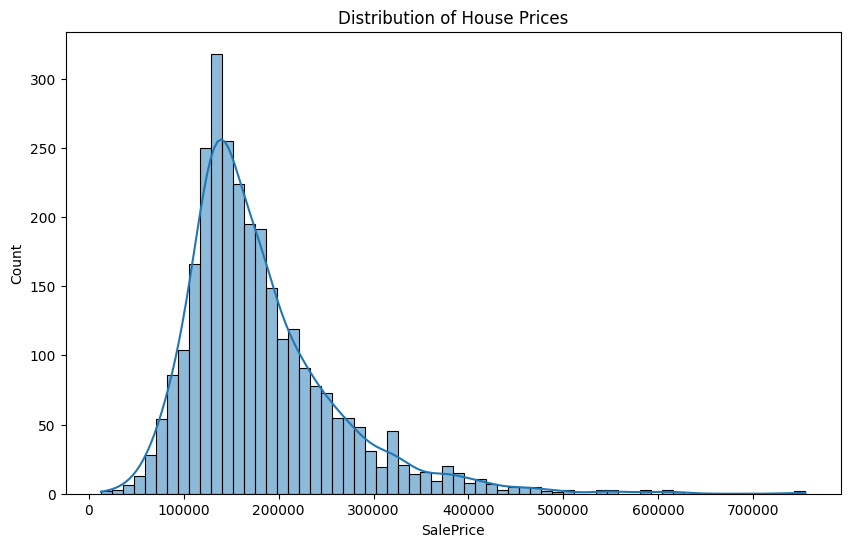

In [4]:
# Exploratory Data Analysis

plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution of House Prices")
plt.show()

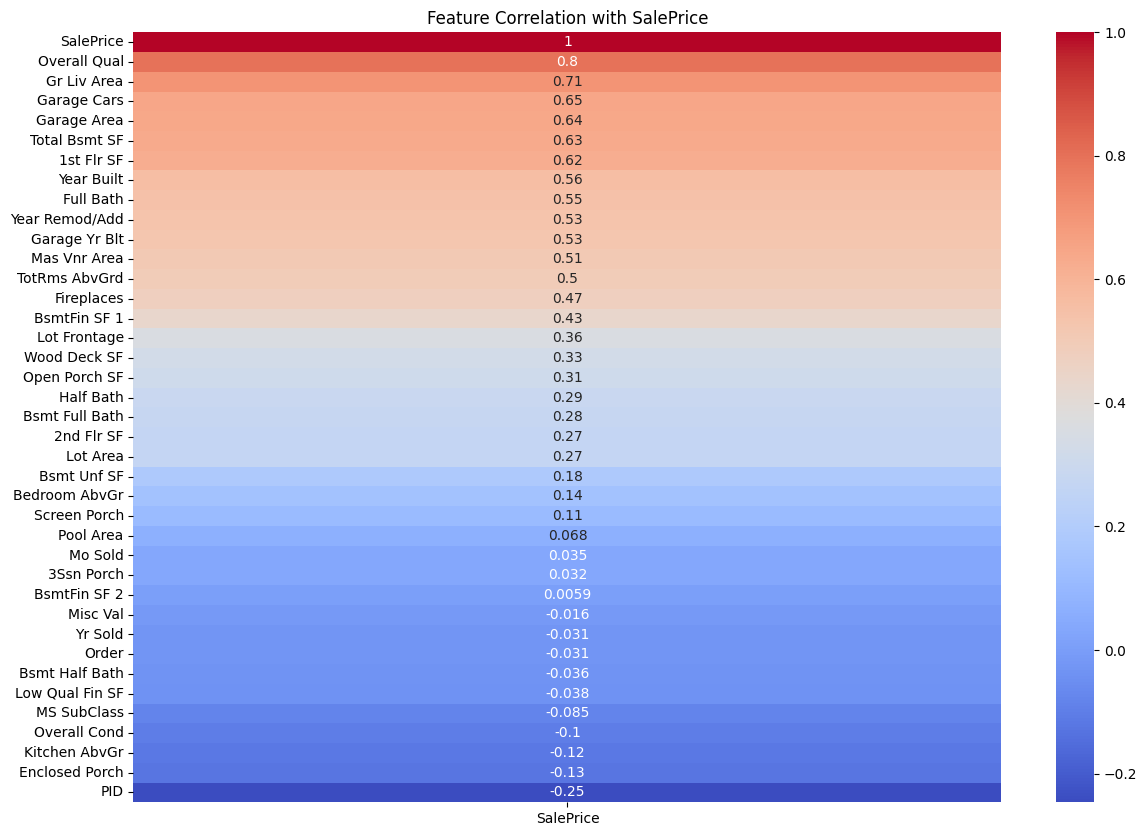

In [5]:
plt.figure(figsize=(14,10))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation[['SalePrice']].sort_values(by='SalePrice', ascending=False),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation with SalePrice")
plt.show()

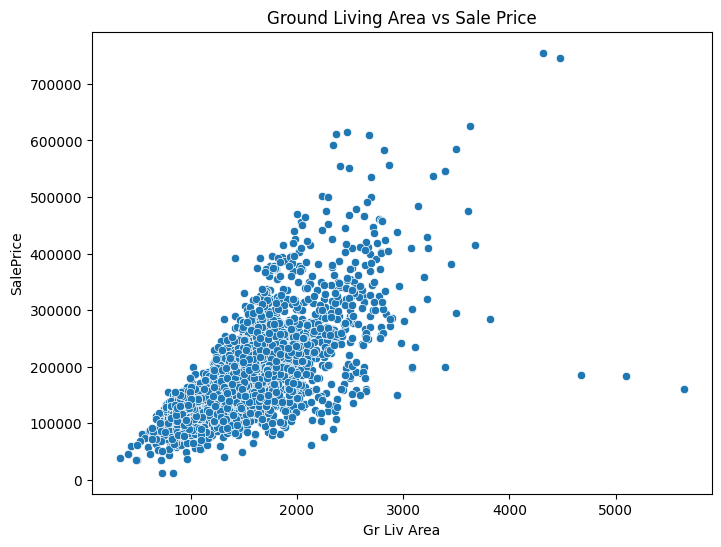

In [6]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=df['Gr Liv Area'], y=df['SalePrice'])

plt.title("Ground Living Area vs Sale Price")
plt.show()

In [7]:
# Feature Selection

selected_features = [
    'Overall Qual',
    'Gr Liv Area',
    'Garage Cars',
    'Garage Area',
    'Total Bsmt SF',
    '1st Flr SF',
    'Year Built',
    'Full Bath',
    'TotRms AbvGrd',
    'Neighborhood'
]

X = df[selected_features]
y = df['SalePrice']

In [8]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Preprocessing Pipeline

numeric_features = [
    'Overall Qual',
    'Gr Liv Area',
    'Garage Cars',
    'Garage Area',
    'Total Bsmt SF',
    '1st Flr SF',
    'Year Built',
    'Full Bath',
    'TotRms AbvGrd'
]

categorical_features = ['Neighborhood']

In [10]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [11]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [13]:
# Building Machine Learning Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [14]:
# Train the Model

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
# Make Predictions

y_pred = model.predict(X_test)

In [16]:
# Model Evaluation

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

RMSE: 36156.35285869769
R² Score: 0.8369474229142969


In [17]:
# Interpret Coefficients

regressor = model.named_steps['regressor']

feature_names = (
    numeric_features +
    list(
        model.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_features)
    )
)

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': regressor.coef_
})

print(coefficients.sort_values(by='Coefficient', ascending=False))

                 Feature   Coefficient
19  Neighborhood_GrnHill  90833.401922
34  Neighborhood_StoneBr  57742.589129
28  Neighborhood_NridgHt  42781.448511
27  Neighborhood_NoRidge  42443.174377
1            Gr Liv Area  27434.989955
0           Overall Qual  22909.071553
15  Neighborhood_Crawfor  17717.055837
13  Neighborhood_ClearCr  13200.050434
36  Neighborhood_Veenker  13166.384860
35   Neighborhood_Timber  11756.186176
6             Year Built   9656.438541
4          Total Bsmt SF   7510.045521
2            Garage Cars   5294.287037
3            Garage Area   4250.630693
5             1st Flr SF   2774.938122
33  Neighborhood_Somerst   1528.152944
12  Neighborhood_BrkSide  -2082.706459
7              Full Bath  -2252.526908
14  Neighborhood_CollgCr  -3309.659448
8          TotRms AbvGrd  -3828.150370
31   Neighborhood_Sawyer  -5950.868998
17  Neighborhood_Gilbert  -6586.595192
24    Neighborhood_NAmes  -8311.534948
23  Neighborhood_Mitchel  -8757.390508
16  Neighborhood_Edwards 

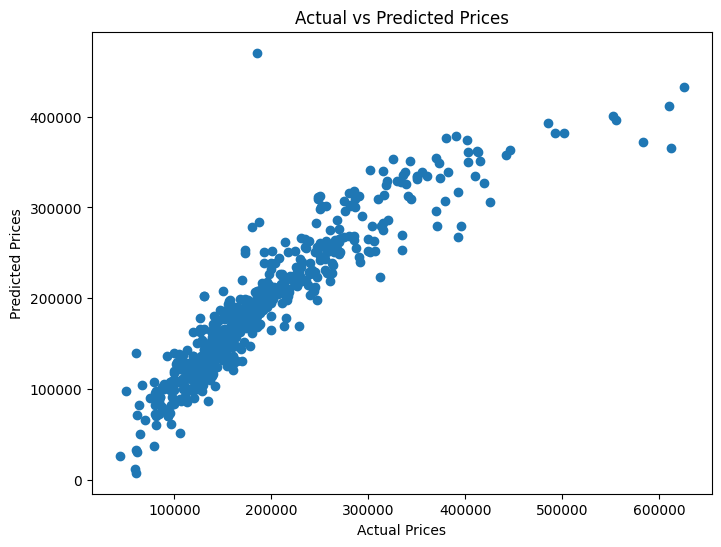

In [18]:
# Actual vs Predicted Graph

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [19]:
# Save Model

joblib.dump(model, 'house_price_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


In [20]:
# Load Model Later

loaded_model = joblib.load('house_price_model.pkl')

In [21]:
# Example Prediction

sample_house = pd.DataFrame({
    'Overall Qual': [8],
    'Gr Liv Area': [2000],
    'Garage Cars': [2],
    'Garage Area': [500],
    'Total Bsmt SF': [1000],
    '1st Flr SF': [1200],
    'Year Built': [2010],
    'Full Bath': [2],
    'TotRms AbvGrd': [8],
    'Neighborhood': ['NridgHt']
})

prediction = loaded_model.predict(sample_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 291476.9871751475
